# Day-Ahead Energy Consumption Forecasting

This notebook develops a day-ahead electricity consumption forecasting model for five Norwegian price areas, using data provided by Aneo. Forecasts are produced daily for the following 24 hours, under the constraint that consumption data is only available with a 5-day delay.

**Pipeline overview:**

1. **Setup and Data Loading** — Load the raw dataset
2. **Data Preparation** — Filter to Norwegian locations, apply per-location z-score normalization, and engineer features from temperature forecasts and lagged consumption
3. **Train/Test Framework** — Expanding-window day-ahead splits with leakage assertions. Multi-fold tune window for hyperparameter selection, 14-day test window for final evaluation
4. **Model Training** — LightGBM with linear trees, tuned via Optuna on late tune folds with location-balanced sample weights
5. **Per-Location Model Selection** — Automatically determine whether the model or a naive baseline is better for each location, decided on the tune window
6. **Test Backtest** — 14-day walk-forward evaluation with per-location model/baseline routing
7. **Baselines** — Three naive lag-based baselines establishing the minimum performance bar
8. **Evaluation** — Overall, per-location, hourly, and weekday/weekend error analysis
9. **Model Diagnostics** — Feature importance, partial dependence, residual autocorrelation, and tree structure analysis
10. **Model Comparison** - compare with other models
11. **SHAP and LIME** - visualize the model's decisions

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
import lightgbm as lgb
import optuna
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
import lime
import lime.lime_tabular
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
df = pd.read_csv('consumption_temp.csv')
df.head(5)

,time,location,consumption,temperature
0,2022-04-07 21:00:00,bergen,1.113325,-0.3
1,2022-04-07 21:00:00,oslo,4.092830,1.0
2,2022-04-07 21:00:00,stavanger,2.057858,1.3
3,2022-04-07 21:00:00,tromsø,1.246582,-3.9
4,2022-04-07 21:00:00,trondheim,1.970098,-2.8


In [3]:
DELAY_DAYS = 5
TEST_DAYS = 14
VAL_DAYS = 14
TUNE_FOLDS = 4
TUNE_FOLD_DAYS = 14

## 2. Data Preparation

### 2.1 Preprocessing

We filter the dataset to the five Norwegian price areas, dropping Helsingfors due to data quality issues and differing consumption patterns.

In [4]:
def preprocess_data(df):
    """Filter to Norwegian locations, convert time, set index, sort."""
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["time"])
    df["location"] = df["location"].astype(str).str.strip().str.lower()

    norwegian = ["bergen", "oslo", "stavanger", "tromsø", "trondheim"]
    df = df[df["location"].isin(norwegian)].copy()

    df = df.set_index("datetime").sort_index()
    df = df.drop(columns=["time"])
    return df

In [5]:
norw_df = preprocess_data(df)
norw_df.head(5)

,location,consumption,temperature
datetime,,,
2022-04-07 21:00:00,bergen,1.113325,-0.3
2022-04-07 21:00:00,oslo,4.092830,1.0
2022-04-07 21:00:00,stavanger,2.057858,1.3
2022-04-07 21:00:00,tromsø,1.246582,-3.9
2022-04-07 21:00:00,trondheim,1.970098,-2.8


### 2.2 Target Standardization

Consumption values vary significantly across locations (Oslo ~10 MW vs Tromsø ~1.5 MW). We apply per-location z-score normalization using an expanding window shifted by the 5-day delay to prevent leakage. At any point in time, the normalization statistics only use consumption values that would have been available in production.

In [6]:
def add_location_standardization(data, target_col="consumption", delay_days=5):
    """Z-score normalize consumption per location using expanding window on delayed data."""
    delay_h = delay_days * 24
    out = data.copy()

    grp = out.groupby("location")[target_col]
    shifted = grp.shift(delay_h)

    out["_loc_mean"] = shifted.groupby(out["location"]).transform(
        lambda x: x.expanding(min_periods=168).mean()
    )
    out["_loc_std"] = shifted.groupby(out["location"]).transform(
        lambda x: x.expanding(min_periods=168).std()
    )
    out["consumption_z"] = (out[target_col] - out["_loc_mean"]) / out["_loc_std"]
    return out


def invert_standardization(predictions_df, data):
    """Convert z-score predictions back to MW using stored per-row location stats."""
    out = predictions_df.copy()
    stats = data[["location", "_loc_mean", "_loc_std"]].copy()
    stats["timestamp"] = stats.index
    out = out.merge(
        stats[["timestamp", "location", "_loc_mean", "_loc_std"]],
        on=["timestamp", "location"],
        how="left",
    )
    out["y_pred_mw"] = out["y_pred"] * out["_loc_std"] + out["_loc_mean"]
    out["y_true_mw"] = out["y_true"] * out["_loc_std"] + out["_loc_mean"]
    return out

### 2.3 Feature Engineering

Features are designed around three information sources available at forecast time: calendar/daylight features, temperature forecasts (available for the target day), and consumption lags (respecting the 5-day delay). All computations are grouped by location to prevent cross-location contamination.

In [7]:
def daylight_hours(latitude, day_of_year):
    """Approximate daylight hours using the solar declination model."""
    lat_rad = np.radians(latitude)
    declination = 23.45 * np.sin(np.radians(360 / 365 * (day_of_year - 81)))
    decl_rad = np.radians(declination)
    cos_ha = np.clip(-np.tan(lat_rad) * np.tan(decl_rad), -1, 1)
    return 2 * np.degrees(np.arccos(cos_ha)) / 15


def add_features(df, delay_days=5):
    """Feature engineering. Expects standardization columns already present."""
    out = df.copy()
    delay_h = delay_days * 24

    # --- Location ---
    out["location"] = out["location"].astype("category")
    lat_map = {
        "bergen": 60.39, "oslo": 59.91, "stavanger": 58.97,
        "tromsø": 69.65, "trondheim": 63.43,
    }
    out["latitude"] = out["location"].map(lat_map)

    # --- Calendar ---
    hour = out.index.hour
    dow = out.index.dayofweek
    out["hour"] = hour
    out["dow"] = dow
    out["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    out["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    out["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    out["day_of_year"] = out.index.dayofyear

    # --- Daylight ---
    out["daylight_hours"] = daylight_hours(
        out["latitude"].astype(float).values, out["day_of_year"].values
    )
    out["daylight_change_7d"] = (
        out["daylight_hours"] - out.groupby("location")["daylight_hours"].shift(168)
    )

    # --- Temperature ---
    out["heating_degree_18"] = np.maximum(0.0, 18.0 - out["temperature"])

    shifted_temp = out.groupby("location")["temperature"].shift(1)
    out["temp_roll_mean_24"] = shifted_temp.groupby(out["location"]).transform(
        lambda x: x.rolling(24, min_periods=24).mean()
    )
    out["temp_roll_mean_168"] = shifted_temp.groupby(out["location"]).transform(
        lambda x: x.rolling(168, min_periods=168).mean()
    )
    out["temp_delta_24h"] = out["temperature"] - out.groupby("location")["temperature"].shift(24)

    out["_date"] = out.index.date
    out["temp_day_mean"] = out.groupby(["location", "_date"])["temperature"].transform("mean")
    out.drop(columns=["_date"], inplace=True)

    out["temp_at_time_1d"] = out.groupby("location")["temperature"].shift(24)
    out["avg_temp_at_time_3d"] = sum(
        out.groupby("location")["temperature"].shift(24 * d) for d in range(1, 4)
    ) / 3.0
    out["avg_temp_at_time_7d"] = sum(
        out.groupby("location")["temperature"].shift(24 * d) for d in range(1, 8)
    ) / 7.0
    out["avg_temp_at_time_14d"] = sum(
        out.groupby("location")["temperature"].shift(24 * d) for d in range(1, 15)
    ) / 14.0

    out["temp_gap_delta"] = (
        out["temperature"] - out.groupby("location")["temperature"].shift(delay_h)
    )

    # --- Consumption lags (z-scored, respecting 5-day delay) ---
    grp_z = out.groupby("location")["consumption_z"]

    out["lag_120"] = grp_z.shift(120)
    out["lag_168"] = grp_z.shift(168)
    out["lag_336"] = grp_z.shift(336)
    out["lag_168_diff"] = out["lag_168"] - out["lag_336"]
    out["lag_120_168_diff"] = out["lag_120"] - out["lag_168"]

    out["avg_cons_at_time_5_7d"] = sum(
        grp_z.shift(24 * d) for d in range(5, 8)
    ) / 3.0
    out["avg_cons_at_time_5_11d"] = sum(
        grp_z.shift(24 * d) for d in range(5, 12)
    ) / 7.0

    avail_z = grp_z.shift(delay_h)
    out["avail_roll_mean_168"] = avail_z.groupby(out["location"]).transform(
        lambda x: x.rolling(168, min_periods=168).mean()
    )
    out["avail_roll_mean_336"] = avail_z.groupby(out["location"]).transform(
        lambda x: x.rolling(336, min_periods=336).mean()
    )

    # --- Recent drift ---
    week_change = (
        out.groupby("location")["consumption_z"].shift(delay_h)
        - out.groupby("location")["consumption_z"].shift(delay_h + 168)
    )
    out["recent_drift_mean_7d"] = week_change.groupby(out["location"]).transform(
        lambda x: x.rolling(168, min_periods=24).mean()
    )

    return out

In [8]:
cons_z = add_location_standardization(norw_df)
data = add_features(cons_z).dropna()
data.head(2)

/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_19031/1209866659.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out["daylight_hours"] - out.groupby("location")["daylight_hours"].shift(168)
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_19031/1209866659.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shifted_temp = out.groupby("location")["temperature"].shift(1)
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_19031/1209866659.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fal

,location,consumption,temperature,_loc_mean,_loc_std,consumption_z,latitude,hour,dow,hour_sin,...,lag_120,lag_168,lag_336,lag_168_diff,lag_120_168_diff,avg_cons_at_time_5_7d,avg_cons_at_time_5_11d,avail_roll_mean_168,avail_roll_mean_336,recent_drift_mean_7d
datetime,,,,,,,,,,,,,,,,,,,,,
2022-05-08 19:00:00,bergen,0.908972,8.0,0.820844,0.158947,0.554449,60.39,19,6,-0.965926,...,0.314885,0.097733,-1.128623,1.226355,0.217153,0.258935,0.157062,-0.604792,-1.601372,1.993161
2022-05-08 19:00:00,oslo,2.831582,11.8,2.809865,0.477492,0.045481,59.91,19,6,-0.965926,...,0.313790,0.286172,-0.258996,0.545168,0.027618,0.248852,0.246411,-0.510144,-1.301784,1.583280


## 3. Train/Test Framework

### 3.1 Expanding Window Splits

The splitting strategy simulates production-realistic day-ahead forecasting. For each forecast day D, training uses all data up to D-5 (the availability cutoff). Tune splits include a 14-day validation set for early stopping. Test splits use all available data for training with frozen hyperparameters.

Four tune folds are spread evenly across the available data to prevent seasonal overfitting of hyperparameters.

In [9]:
@dataclass
class ForecastSplit:
    """One day-ahead forecast unit."""
    forecast_date: pd.Timestamp
    avail_cutoff: pd.Timestamp
    X_train: pd.DataFrame
    y_train: pd.Series
    X_val: pd.DataFrame
    y_val: pd.Series
    X_test: pd.DataFrame
    y_test: pd.Series


def build_day_ahead_splits(
    data, forecast_days, target_col="consumption_z",
    val_days=14, delay_days=5, include_val=True,
):
    """Expanding-window day-ahead splits respecting consumption delay."""
    exclude = {target_col, "consumption", "_loc_mean", "_loc_std"}
    feature_cols = [c for c in data.columns if c not in exclude]
    splits = []

    for D in forecast_days:
        D = D.normalize()
        test_data = data[(data.index >= D) & (data.index < D + pd.Timedelta(days=1))]
        if test_data.empty:
            continue

        avail_day = (D - pd.Timedelta(days=delay_days)).normalize()
        avail_cutoff = avail_day + pd.Timedelta(hours=23)
        available = data[data.index <= avail_cutoff]

        if include_val:
            val_start = (avail_day - pd.Timedelta(days=val_days - 1)).normalize()
            val_data = available[available.index >= val_start]
            train_data = available[available.index < val_start]
            if train_data.empty or val_data.empty:
                continue
        else:
            train_data = available
            val_data = available.iloc[:0]
            if train_data.empty:
                continue

        splits.append(ForecastSplit(
            forecast_date=D, avail_cutoff=avail_cutoff,
            X_train=train_data[feature_cols], y_train=train_data[target_col],
            X_val=val_data[feature_cols], y_val=val_data[target_col],
            X_test=test_data[feature_cols], y_test=test_data[target_col],
        ))
    return splits


def build_multi_fold_tune_splits(
    data, test_start, n_folds=4, fold_days=14, val_days=14, delay_days=5,
):
    """Create multiple tune folds spread evenly across available data."""
    data_start = data.index.min().normalize() + pd.Timedelta(days=60)
    data_end = test_start - pd.Timedelta(days=1)
    spacing = (data_end - data_start).days // (n_folds + 1)

    all_splits, fold_info = [], []
    for fold in range(n_folds):
        fold_end = data_start + pd.Timedelta(days=spacing * (fold + 1))
        fold_start = fold_end - pd.Timedelta(days=fold_days - 1)
        fold_range = pd.date_range(fold_start, fold_end, freq="D")

        fold_splits = build_day_ahead_splits(
            data, fold_range, val_days=val_days,
            delay_days=delay_days, include_val=True,
        )
        all_splits.extend(fold_splits)
        if fold_splits:
            fold_info.append((
                fold_splits[0].forecast_date.date(),
                fold_splits[-1].forecast_date.date(),
                len(fold_splits),
            ))
    return all_splits, fold_info

In [10]:
target_col = "consumption_z"
last_day = data.index.max().normalize()

test_end = last_day
test_start = test_end - pd.Timedelta(days=TEST_DAYS - 1)
test_day_range = pd.date_range(test_start, test_end, freq="D")

tune_splits, fold_info = build_multi_fold_tune_splits(
    data, test_start, n_folds=TUNE_FOLDS, fold_days=TUNE_FOLD_DAYS,
    val_days=VAL_DAYS, delay_days=DELAY_DAYS,
)

test_splits = build_day_ahead_splits(
    data, test_day_range, delay_days=DELAY_DAYS, include_val=False,
)

# --- Leakage assertions ---
for label, splits, has_val in [("TUNE", tune_splits, True), ("TEST", test_splits, False)]:
    for s in splits:
        D = s.forecast_date
        gap_start = (D - pd.Timedelta(days=DELAY_DAYS - 1)).normalize()
        assert s.X_train.index.max() < gap_start
        assert s.X_train.index.max() <= s.avail_cutoff
        if has_val:
            assert s.X_val.index.max() < gap_start
            assert s.X_val.index.max() <= s.avail_cutoff
            assert s.X_train.index.max() < s.X_val.index.min()

print(f"TUNE: {len(tune_splits)} splits across {len(fold_info)} folds:")
for start, end, n in fold_info:
    print(f"  Fold {start} → {end} ({n} days)")

s0, sN = test_splits[0], test_splits[-1]
print(f"\nTEST window: {s0.forecast_date.date()} -> {sN.forecast_date.date()} ({len(test_splits)} days)")
print(f"  first: avail={s0.avail_cutoff.date()}, train={len(s0.y_train):,} rows")
print(f"  last:  avail={sN.avail_cutoff.date()}, train={len(sN.y_train):,} rows")

TUNE: 56 splits across 4 folds:
  Fold 2022-08-14 → 2022-08-27 (14 days)
  Fold 2022-10-04 → 2022-10-17 (14 days)
  Fold 2022-11-24 → 2022-12-07 (14 days)
  Fold 2023-01-14 → 2023-01-27 (14 days)

TEST window: 2023-03-20 -> 2023-04-02 (14 days)
  first: avail=2023-03-15, train=37,345 rows
  last:  avail=2023-03-28, train=38,905 rows


## 4. Model Training

### 4.1 Model Setup and Metrics

The primary model is a LightGBM regressor with L1 (MAE) objective and linear trees. Location-balanced sample weights (sqrt-inverse of mean consumption) ensure the model doesn't disproportionately optimize for high-consumption locations like Oslo.

In [11]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

target_col = "consumption_z"
exclude = {"consumption", "consumption_z", "_loc_mean", "_loc_std"}
feature_cols = [c for c in data.columns if c not in exclude]
cat_features = ["location"]


def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

def smape(y_true, y_pred, eps=1e-9):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = np.maximum((np.abs(y_true) + np.abs(y_pred)) / 2.0, eps)
    return float(np.mean(np.abs(y_true - y_pred) / denom)) * 100.0


def location_balance_weights(X_train):
    """Sqrt-inverse of location mean consumption, normalized to average 1."""
    loc_means = data.loc[X_train.index].groupby("location")["consumption"].mean()
    inv_means = 1.0 / np.sqrt(loc_means)
    inv_means = inv_means / inv_means.mean()
    return X_train["location"].map(inv_means).astype(float).values


def make_model(params):
    """LightGBM with L1 objective and linear trees."""
    base = dict(
        objective="regression_l1", boosting_type="gbdt",
        n_estimators=2000, bagging_freq=1, linear_tree=True,
        random_state=42, n_jobs=-1, verbosity=-1,
    )
    base.update(params)
    return lgb.LGBMRegressor(**base)

### 4.2 Hyperparameter Tuning

Optuna tunes hyperparameters on the last 2 tune folds only (Nov–Dec and Jan), which have sufficient training data to produce reliable early stopping. The 75th percentile of early stopping iterations is used as the fixed `n_estimators` for test evaluation.

In [12]:
def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 7, 31),
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "min_child_samples": trial.suggest_int("min_child_samples", 30, 150),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.1, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "path_smooth": trial.suggest_float("path_smooth", 0.0, 10.0),
        "extra_trees": trial.suggest_categorical("extra_trees", [True, False]),
    }

    late_folds = tune_splits[len(tune_splits) // 2:]
    tune_subset = late_folds[::3]
    scores, best_iters = [], []

    for step, split in enumerate(tune_subset):
        model = make_model({**params, "n_estimators": 1000})
        weights = location_balance_weights(split.X_train)
        model.fit(
            split.X_train, split.y_train, sample_weight=weights,
            eval_set=[(split.X_val, split.y_val)], eval_metric="l1",
            callbacks=[lgb.early_stopping(50, verbose=False)],
            categorical_feature=cat_features,
        )
        best_iters.append(model.best_iteration_)
        scores.append(mae(split.y_val.values, model.predict(split.X_val)))

        trial.report(np.mean(scores), step)
        if trial.should_prune():
            raise optuna.TrialPruned()

    trial.set_user_attr("n_estimators", int(np.percentile(best_iters, 75)))
    return float(np.mean(scores))


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=2),
)
study.optimize(objective, n_trials=25, show_progress_bar=True)

best_params = study.best_trial.params
best_n_estimators = study.best_trial.user_attrs["n_estimators"]

print(f"\nBest tune MAE: {study.best_value:.4f}")
print(f"Best params:   {best_params}")
print(f"Best n_estimators (75th pct early stop): {best_n_estimators}")

  0%|          | 0/25 [00:00<?, ?it/s]

/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_19031/1232580367.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_means = data.loc[X_train.index].groupby("location")["consumption"].mean()
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_19031/1232580367.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_means = data.loc[X_train.index].groupby("location")["consumption"].mean()
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_19031/1232580367.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. P


Best tune MAE: 0.4105
Best params:   {'learning_rate': 0.032491530533916, 'num_leaves': 7, 'max_depth': 5, 'min_child_samples': 70, 'reg_lambda': 1.1516719627385013, 'reg_alpha': 0.17714269871565663, 'subsample': 0.8070733224593357, 'colsample_bytree': 0.6117451704166061, 'path_smooth': 2.382567484038675, 'extra_trees': True}
Best n_estimators (75th pct early stop): 267


In [13]:
print("Best hyperparameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

print(f"\nbest_n_estimators: {best_n_estimators}")

Best hyperparameters:
  learning_rate: 0.032491530533916
  num_leaves: 7
  max_depth: 5
  min_child_samples: 70
  reg_lambda: 1.1516719627385013
  reg_alpha: 0.17714269871565663
  subsample: 0.8070733224593357
  colsample_bytree: 0.6117451704166061
  path_smooth: 2.382567484038675
  extra_trees: True

best_n_estimators: 267


## 5. Per-Location Model Selection

For each location, we compare the model against the naive baseline (average of lag 120h + 168h) on the last tune fold's forecast days. If the baseline wins, that location uses baseline predictions at test time. The decision uses three-way data separation: train → val (early stopping) → test (evaluation), with no test data leakage.

In [14]:
lookup = data.reset_index().set_index(["datetime", "location"])


def baseline_avg_at_timestamps(timestamps, locations):
    """Average of lag 120h + 168h baseline, in raw MW."""
    preds = []
    for ts, loc in zip(timestamps, locations):
        try:
            lag5 = lookup.loc[(ts - pd.Timedelta(hours=120), loc), "consumption"]
            lag7 = lookup.loc[(ts - pd.Timedelta(hours=168), loc), "consumption"]
            preds.append((lag5 + lag7) / 2.0)
        except KeyError:
            preds.append(np.nan)
    return np.array(preds)


# Evaluate on last tune fold's forecast days
last_fold_start = tune_splits[-1].forecast_date - pd.Timedelta(days=13)
last_fold_splits = [s for s in tune_splits if s.forecast_date >= last_fold_start]

tune_eval_rows = []
for split in last_fold_splits:
    model = make_model({**best_params, "n_estimators": 1000})
    weights = location_balance_weights(split.X_train)
    model.fit(
        split.X_train, split.y_train, sample_weight=weights,
        eval_set=[(split.X_val, split.y_val)], eval_metric="l1",
        callbacks=[lgb.early_stopping(50, verbose=False)],
        categorical_feature=cat_features,
    )

    y_pred_z = model.predict(split.X_test)
    timestamps = split.X_test.index
    locations = split.X_test["location"].values

    for idx, (ts, loc) in enumerate(zip(timestamps, locations)):
        row_data = data.loc[ts]
        if isinstance(row_data, pd.DataFrame):
            row_data = row_data[row_data["location"] == loc].iloc[0]
        loc_mean, loc_std = row_data["_loc_mean"], row_data["_loc_std"]
        tune_eval_rows.append({
            "timestamp": ts, "location": loc,
            "y_true_mw": split.y_test.iloc[idx] * loc_std + loc_mean,
            "y_pred_model_mw": y_pred_z[idx] * loc_std + loc_mean,
        })

tune_eval = pd.DataFrame(tune_eval_rows)
tune_eval["y_pred_baseline_mw"] = baseline_avg_at_timestamps(
    tune_eval["timestamp"].values, tune_eval["location"].values,
)
tune_eval = tune_eval.dropna(subset=["y_pred_baseline_mw"])

use_model = {}
print(f"Per-location model selection (last tune fold: "
      f"{last_fold_splits[0].forecast_date.date()} -> {last_fold_splits[-1].forecast_date.date()}):\n")

for loc in sorted(tune_eval["location"].unique()):
    loc_data = tune_eval[tune_eval["location"] == loc]
    m_smape = smape(loc_data["y_true_mw"], loc_data["y_pred_model_mw"])
    b_smape = smape(loc_data["y_true_mw"], loc_data["y_pred_baseline_mw"])
    use_model[loc] = m_smape <= b_smape
    print(f"  {loc.capitalize():12s}: model={m_smape:.2f}%, baseline={b_smape:.2f}% → "
          f"{'MODEL' if use_model[loc] else 'BASELINE'}")

print(f"\nUsing model:    {[l for l, v in use_model.items() if v]}")
print(f"Using baseline: {[l for l, v in use_model.items() if not v]}")

/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_19031/1232580367.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_means = data.loc[X_train.index].groupby("location")["consumption"].mean()
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_19031/1232580367.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_means = data.loc[X_train.index].groupby("location")["consumption"].mean()
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_19031/1232580367.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. P

Per-location model selection (last tune fold: 2023-01-14 -> 2023-01-27):

  Bergen      : model=9.18%, baseline=13.09% → MODEL
  Oslo        : model=9.23%, baseline=11.88% → MODEL
  Stavanger   : model=8.32%, baseline=12.37% → MODEL
  Tromsø      : model=10.64%, baseline=5.32% → BASELINE
  Trondheim   : model=9.94%, baseline=10.47% → MODEL

Using model:    ['bergen', 'oslo', 'stavanger', 'trondheim']
Using baseline: ['tromsø']


## 6. Test Backtest

14-day walk-forward evaluation. For each test day, the model is retrained on all available data. Locations flagged for baseline fallback receive lag-average predictions converted to z-score for uniform inversion.

In [15]:
pred_rows, daily_rows = [], []

print("Running TEST backtest (model + baseline fallback)\n")

for i, split in enumerate(test_splits, start=1):
    model = make_model({**best_params, "n_estimators": best_n_estimators})
    weights = location_balance_weights(split.X_train)
    model.fit(split.X_train, split.y_train,
              sample_weight=weights, categorical_feature=cat_features)

    y_pred_z = model.predict(split.X_test)
    y_true = split.y_test.values
    locations = split.X_test["location"].values
    timestamps = split.X_test.index

    y_pred_final_z = y_pred_z.copy()
    baseline_preds = baseline_avg_at_timestamps(timestamps, locations)

    for idx, loc in enumerate(locations):
        if not use_model[loc] and not np.isnan(baseline_preds[idx]):
            row_data = data.loc[timestamps[idx]]
            if isinstance(row_data, pd.DataFrame):
                row_data = row_data[row_data["location"] == loc].iloc[0]
            y_pred_final_z[idx] = (baseline_preds[idx] - row_data["_loc_mean"]) / row_data["_loc_std"]

    daily_rows.append({
        "forecast_date": split.forecast_date,
        "MAE": mae(y_true, y_pred_final_z),
        "RMSE": rmse(y_true, y_pred_final_z),
        "SMAPE_%": smape(y_true, y_pred_final_z),
    })

    pred_rows.append(pd.DataFrame({
        "forecast_date": split.forecast_date,
        "timestamp": timestamps,
        "location": locations,
        "y_true": y_true,
        "y_pred": y_pred_final_z,
    }))

    print(f"  Day {i:>2}/{len(test_splits)}  {split.forecast_date.date()}  "
          f"train={len(split.y_train):,}  "
          f"MAE={mae(y_true, y_pred_final_z):.4f}  RMSE={rmse(y_true, y_pred_final_z):.4f}")

predictions = pd.concat(pred_rows, ignore_index=True)
predictions = invert_standardization(predictions, data)

daily_metrics = pd.DataFrame([{
    "forecast_date": D,
    "MAE": mae(grp["y_true_mw"], grp["y_pred_mw"]),
    "RMSE": rmse(grp["y_true_mw"], grp["y_pred_mw"]),
    "SMAPE_%": smape(grp["y_true_mw"], grp["y_pred_mw"]),
} for D, grp in predictions.groupby("forecast_date")])

print(f"\n{'='*50}")
print(f"Overall MAE:   {daily_metrics['MAE'].mean():.4f} MW")
print(f"Overall RMSE:  {daily_metrics['RMSE'].mean():.4f} MW")
print(f"Overall SMAPE: {daily_metrics['SMAPE_%'].mean():.2f}%")

Running TEST backtest (model + baseline fallback)



/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_19031/1232580367.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_means = data.loc[X_train.index].groupby("location")["consumption"].mean()


  Day  1/14  2023-03-20  train=37,345  MAE=0.1835  RMSE=0.2339


/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_19031/1232580367.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_means = data.loc[X_train.index].groupby("location")["consumption"].mean()


  Day  2/14  2023-03-21  train=37,465  MAE=0.1516  RMSE=0.1832


...

  Day 12/14  2023-03-31  train=38,665  MAE=0.1721  RMSE=0.2098


/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_19031/1232580367.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_means = data.loc[X_train.index].groupby("location")["consumption"].mean()


  Day 13/14  2023-04-01  train=38,785  MAE=0.1316  RMSE=0.1549


/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_19031/1232580367.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_means = data.loc[X_train.index].groupby("location")["consumption"].mean()


  Day 14/14  2023-04-02  train=38,905  MAE=0.1431  RMSE=0.1748

Overall MAE:   0.2651 MW
Overall RMSE:  0.3731 MW
Overall SMAPE: 5.64%


In [16]:
print("\nMetrics by location:")
for loc in sorted(predictions["location"].unique()):
    loc_data = predictions[predictions["location"] == loc]
    print(f"  {loc.capitalize():12s}: MAE={mae(loc_data['y_true_mw'], loc_data['y_pred_mw']):.4f} MW, "
          f"RMSE={rmse(loc_data['y_true_mw'], loc_data['y_pred_mw']):.4f} MW, "
          f"SMAPE={smape(loc_data['y_true_mw'], loc_data['y_pred_mw']):.2f}%")


Metrics by location:
  Bergen      : MAE=0.1569 MW, RMSE=0.1899 MW, SMAPE=5.51%
  Oslo        : MAE=0.5153 MW, RMSE=0.6449 MW, SMAPE=4.72%
  Stavanger   : MAE=0.3457 MW, RMSE=0.4469 MW, SMAPE=6.75%
  Tromsø      : MAE=0.0986 MW, RMSE=0.1204 MW, SMAPE=5.22%
  Trondheim   : MAE=0.2088 MW, RMSE=0.2487 MW, SMAPE=6.03%


In [17]:
predictions.to_csv("predictions.csv", index=False)
daily_metrics.to_csv("daily_metrics.csv", index=False)
print(f"Saved predictions ({len(predictions)} rows) and daily_metrics ({len(daily_metrics)} rows)")

Saved predictions (1670 rows) and daily_metrics (14 rows)


## 7. Baselines

Three naive baselines establish the minimum performance bar. All respect the 5-day delay.

In [18]:
def lookup_consumption(timestamps, locations):
    return np.array([lookup.loc[(ts, loc), "consumption"]
                     for ts, loc in zip(timestamps, locations)])


def evaluate_baseline(name, test_splits, predict_fn):
    """Run a baseline predictor over test splits. Both y_true and y_pred in MW."""
    pred_rows, daily_rows = [], []
    for split in test_splits:
        locs = split.X_test["location"].values
        ts = split.X_test.index
        y_true = lookup_consumption(ts, locs)
        y_pred = predict_fn(split)
        daily_rows.append({"forecast_date": split.forecast_date,
                           "MAE": mae(y_true, y_pred), "RMSE": rmse(y_true, y_pred),
                           "SMAPE_%": smape(y_true, y_pred)})
        pred_rows.append(pd.DataFrame({"forecast_date": split.forecast_date,
                                       "timestamp": ts, "location": locs,
                                       "y_true": y_true, "y_pred": y_pred}))
    metrics = pd.DataFrame(daily_rows)
    preds = pd.concat(pred_rows, ignore_index=True)
    print(f"── {name} ──")
    print(f"   MAE:   {metrics['MAE'].mean():.4f} MW")
    print(f"   RMSE:  {metrics['RMSE'].mean():.4f} MW")
    print(f"   SMAPE: {metrics['SMAPE_%'].mean():.2f}%\n")
    return metrics, preds

lag216_metrics, lag216_preds = evaluate_baseline(
    "Lag 216h (9)", test_splits,
    lambda s: lookup_consumption(s.X_test.index - pd.Timedelta(hours=216), s.X_test["location"].values))

lag192_metrics, lag192_preds = evaluate_baseline(
    "Lag 192h (8 days ago)", test_splits,
    lambda s: lookup_consumption(s.X_test.index - pd.Timedelta(hours=192), s.X_test["location"].values))

lag168_metrics, lag168_preds = evaluate_baseline(
    "Lag 168h (same weekday last week)", test_splits,
    lambda s: lookup_consumption(s.X_test.index - pd.Timedelta(hours=168), s.X_test["location"].values))

lag144_metrics, lag144_preds = evaluate_baseline(
    "Lag 144h (6 days ago)", test_splits,
    lambda s: lookup_consumption(s.X_test.index - pd.Timedelta(hours=144), s.X_test["location"].values))

lag120_metrics, lag120_preds = evaluate_baseline(
    "Lag 120h (5 days ago, earliest available)", test_splits,
    lambda s: lookup_consumption(s.X_test.index - pd.Timedelta(hours=120), s.X_test["location"].values))

#avg 5d 7d
avg_metrics, avg_preds = evaluate_baseline(
    "Average of lag 120h + 168h", test_splits,
    lambda s: (lookup_consumption(s.X_test.index - pd.Timedelta(hours=120), s.X_test["location"].values)
             + lookup_consumption(s.X_test.index - pd.Timedelta(hours=168), s.X_test["location"].values)) / 2.0)

#avg 5d, 6d, 7d
avg_5_7_metrics, avg_5_7_preds = evaluate_baseline(
    "Average of lag 120h, 144h, 168h", test_splits,
    lambda s: (lookup_consumption(s.X_test.index - pd.Timedelta(hours=120), s.X_test["location"].values)
             + lookup_consumption(s.X_test.index - pd.Timedelta(hours=144), s.X_test["location"].values)
             + lookup_consumption(s.X_test.index - pd.Timedelta(hours=168), s.X_test["location"].values)) / 3.0)

#avg 5, 6, 7, 8d
avg_5_8_metrics, avg_5_8_preds = evaluate_baseline(
    "Average of lag 120h, 144h, 168h, 192h", test_splits,
    lambda s: (lookup_consumption(s.X_test.index - pd.Timedelta(hours=120), s.X_test["location"].values)
             + lookup_consumption(s.X_test.index - pd.Timedelta(hours=144), s.X_test["location"].values)
             + lookup_consumption(s.X_test.index - pd.Timedelta(hours=168), s.X_test["location"].values)
             + lookup_consumption(s.X_test.index - pd.Timedelta(hours=192), s.X_test["location"].values)) / 4.0)

#avg 5, 6, 7, 8, 9d
avg_5_9_metrics, avg_5_9_preds = evaluate_baseline(
    "Average of lag 120h, 144h, 168h, 192h, 216h", test_splits,
    lambda s: (lookup_consumption(s.X_test.index - pd.Timedelta(hours=120), s.X_test["location"].values)
             + lookup_consumption(s.X_test.index - pd.Timedelta(hours=144), s.X_test["location"].values)
             + lookup_consumption(s.X_test.index - pd.Timedelta(hours=168), s.X_test["location"].values)
             + lookup_consumption(s.X_test.index - pd.Timedelta(hours=192), s.X_test["location"].values)
             + lookup_consumption(s.X_test.index - pd.Timedelta(hours=216), s.X_test["location"].values)) / 5.0)

#avg 5-10d
avg_5_10_metrics, avg_5_10_preds = evaluate_baseline(
    "Average of lag 120h, 144h, 168h, 192h, 216h, 240h", test_splits,
    lambda s: (lookup_consumption(s.X_test.index - pd.Timedelta(hours=120), s.X_test["location"].values)
             + lookup_consumption(s.X_test.index - pd.Timedelta(hours=144), s.X_test["location"].values)
             + lookup_consumption(s.X_test.index - pd.Timedelta(hours=168), s.X_test["location"].values)
             + lookup_consumption(s.X_test.index - pd.Timedelta(hours=192), s.X_test["location"].values)
             + lookup_consumption(s.X_test.index - pd.Timedelta(hours=216), s.X_test["location"].values)
             + lookup_consumption(s.X_test.index - pd.Timedelta(hours=240), s.X_test["location"].values)) / 6.0)

── Lag 216h (9) ──
   MAE:   0.6488 MW
   RMSE:  0.8971 MW
   SMAPE: 12.24%

── Lag 192h (8 days ago) ──
   MAE:   0.5947 MW
   RMSE:  0.8143 MW
   SMAPE: 11.37%

── Lag 168h (same weekday last week) ──
   MAE:   0.4785 MW
   RMSE:  0.6619 MW
   SMAPE: 9.09%

── Lag 144h (6 days ago) ──
   MAE:   0.5057 MW
   RMSE:  0.7069 MW
   SMAPE: 9.84%

── Lag 120h (5 days ago, earliest available) ──
   MAE:   0.4864 MW
   RMSE:  0.7116 MW
   SMAPE: 9.43%

── Average of lag 120h + 168h ──
   MAE:   0.4530 MW
   RMSE:  0.6376 MW
   SMAPE: 8.71%

── Average of lag 120h, 144h, 168h ──
   MAE:   0.4545 MW
   RMSE:  0.6384 MW
   SMAPE: 8.76%

── Average of lag 120h, 144h, 168h, 192h ──
   MAE:   0.4650 MW
   RMSE:  0.6422 MW
   SMAPE: 8.96%

── Average of lag 120h, 144h, 168h, 192h, 216h ──
   MAE:   0.4832 MW
   RMSE:  0.6665 MW
   SMAPE: 9.27%

── Average of lag 120h, 144h, 168h, 192h, 216h, 240h ──
   MAE:   0.5049 MW
   RMSE:  0.6935 MW
   SMAPE: 9.65%



In [19]:
print("Baseline (avg 120+168) per location:")
for loc in sorted(avg_preds["location"].unique()):
    loc_data = avg_preds[avg_preds["location"] == loc]
    print(f"  {loc.capitalize():12s}: {smape(loc_data['y_true'], loc_data['y_pred']):.2f}%")

Baseline (avg 120+168) per location:
  Bergen      : 9.39%
  Oslo        : 9.73%
  Stavanger   : 10.71%
  Tromsø      : 5.22%
  Trondheim   : 8.67%


In [20]:
avg_preds.to_csv("baseline_avg_120_168_predictions.csv", index=False)

In [21]:
summary = pd.DataFrame({
    "Model": ["Lag 168h (same weekday)", "Lag 120h (5 days ago)",
              "Avg lag 120h + 168h", "LGBM Global (tuned)"],
    "MAE": [lag168_metrics["MAE"].mean(), lag120_metrics["MAE"].mean(),
            avg_metrics["MAE"].mean(), daily_metrics["MAE"].mean()],
    "RMSE": [lag168_metrics["RMSE"].mean(), lag120_metrics["RMSE"].mean(),
             avg_metrics["RMSE"].mean(), daily_metrics["RMSE"].mean()],
    "SMAPE_%": [lag168_metrics["SMAPE_%"].mean(), lag120_metrics["SMAPE_%"].mean(),
               avg_metrics["SMAPE_%"].mean(), daily_metrics["SMAPE_%"].mean()],
})
display(summary.sort_values("MAE").reset_index(drop=True))

,Model,MAE,RMSE,SMAPE_%
0,LGBM Global (tuned),0.265069,0.373067,5.644885
1,Avg lag 120h + 168h,0.453011,0.637559,8.714729
2,Lag 168h (same weekday),0.478533,0.661903,9.090501
3,Lag 120h (5 days ago),0.486363,0.711649,9.425525


## 8. Evaluation

### 8.1 Overall Performance

Daily MAE over the test window for the model and all baselines.

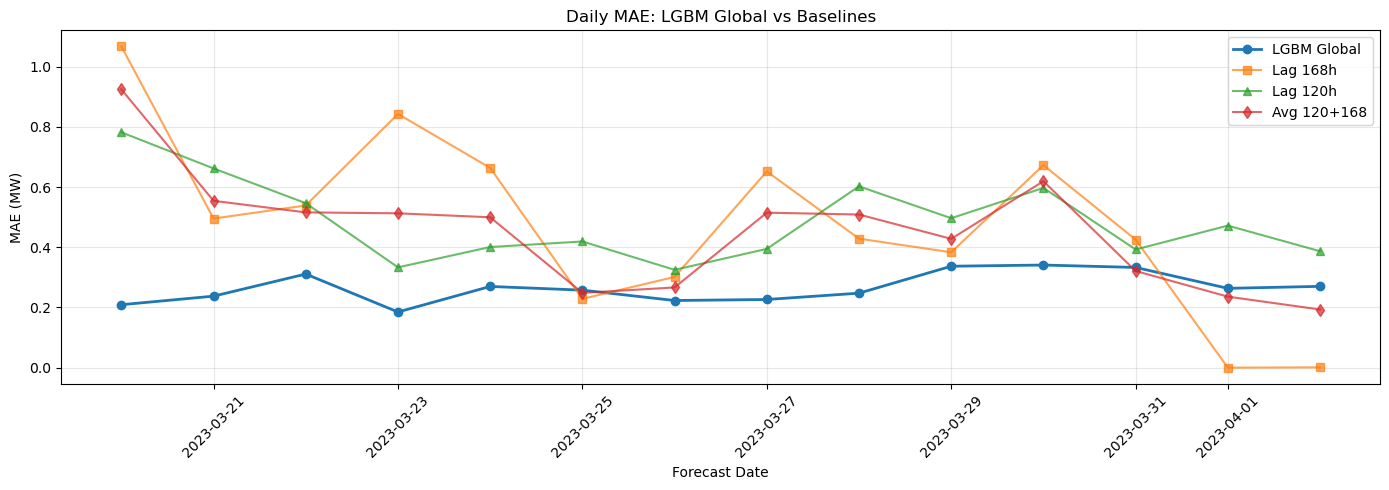

In [22]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_metrics["forecast_date"], daily_metrics["MAE"],
        marker="o", label="LGBM Global", linewidth=2)
ax.plot(lag168_metrics["forecast_date"], lag168_metrics["MAE"],
        marker="s", label="Lag 168h", alpha=0.7)
ax.plot(lag120_metrics["forecast_date"], lag120_metrics["MAE"],
        marker="^", label="Lag 120h", alpha=0.7)
ax.plot(avg_metrics["forecast_date"], avg_metrics["MAE"],
        marker="d", label="Avg 120+168", alpha=0.7)
ax.set(title="Daily MAE: LGBM Global vs Baselines", xlabel="Forecast Date", ylabel="MAE (MW)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

### 8.2 Per-Location Analysis

True vs predicted consumption per location alongside the best baseline.

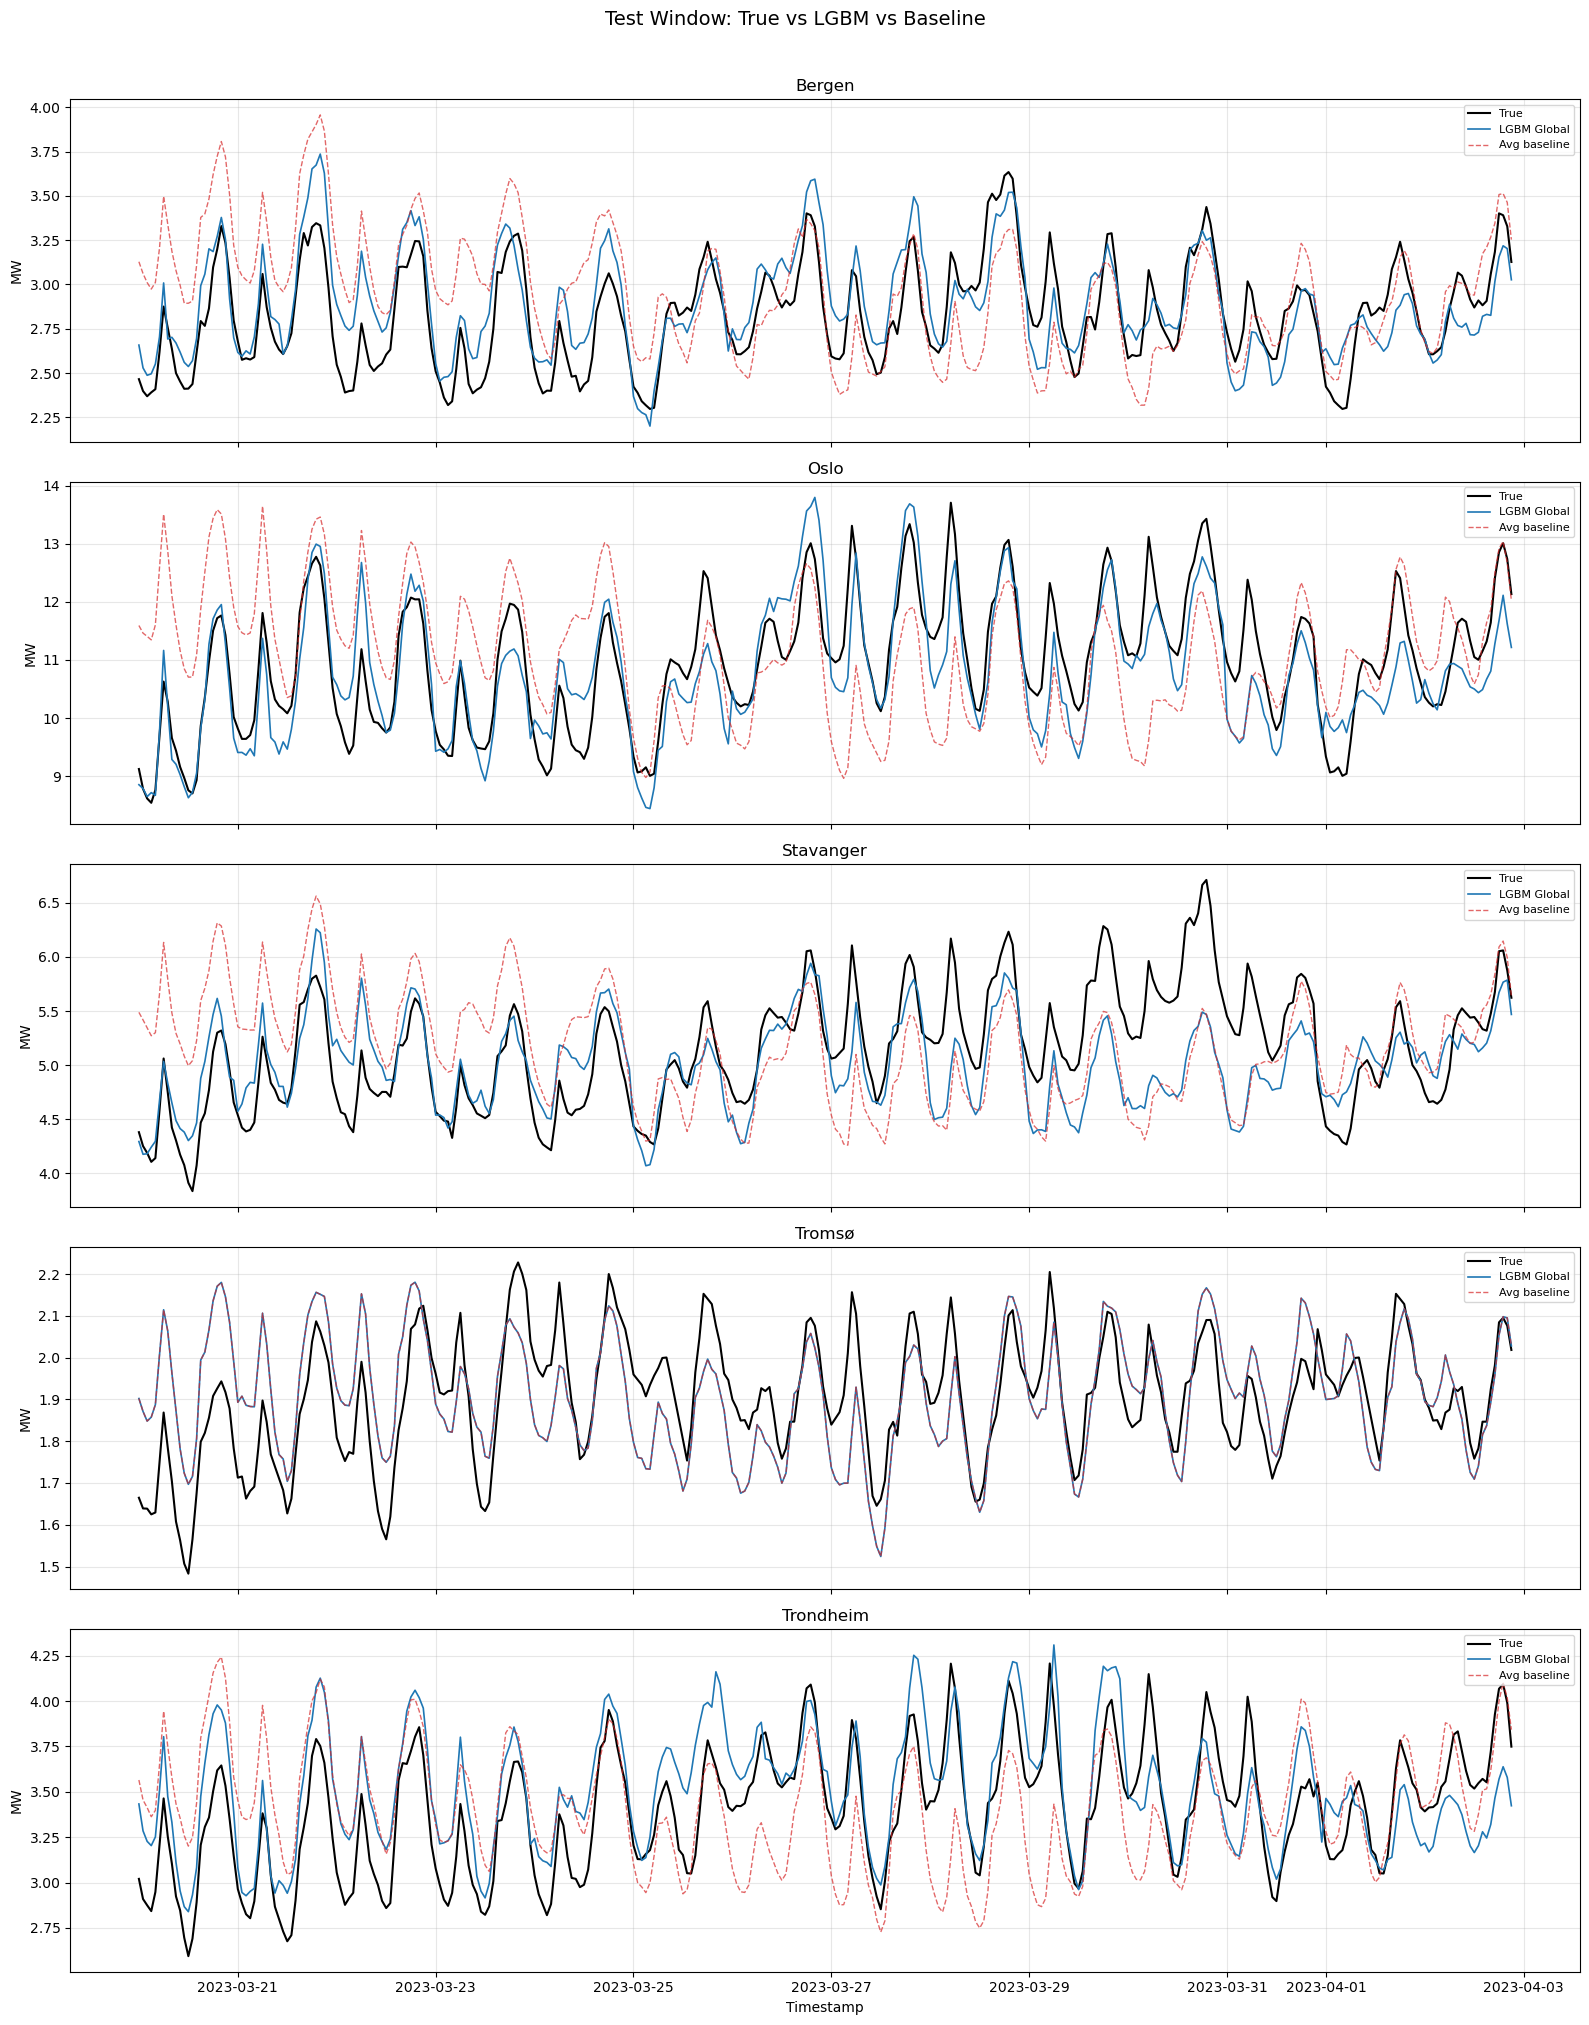

In [23]:
locations = sorted(predictions["location"].unique())
best_baseline = avg_preds.rename(columns={"y_pred": "y_pred_baseline"})

fig, axes = plt.subplots(len(locations), 1, figsize=(16, 4 * len(locations)), sharex=True)
for ax, loc in zip(axes, locations):
    lp = predictions[predictions["location"] == loc].sort_values("timestamp")
    lb = best_baseline[best_baseline["location"] == loc].sort_values("timestamp")
    ax.plot(lp["timestamp"], lp["y_true_mw"], color="black", label="True", linewidth=1.5)
    ax.plot(lp["timestamp"], lp["y_pred_mw"], color="tab:blue", label="LGBM Global", linewidth=1.2)
    ax.plot(lb["timestamp"], lb["y_pred_baseline"], color="tab:red",
            label="Avg baseline", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_title(loc.capitalize()); ax.set_ylabel("MW")
    ax.legend(loc="upper right", fontsize=8); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Timestamp")
plt.suptitle("Test Window: True vs LGBM vs Baseline", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### 8.3 Error Analysis

Error distributions, MAE by hour, MAE by location, and weekday vs weekend performance.

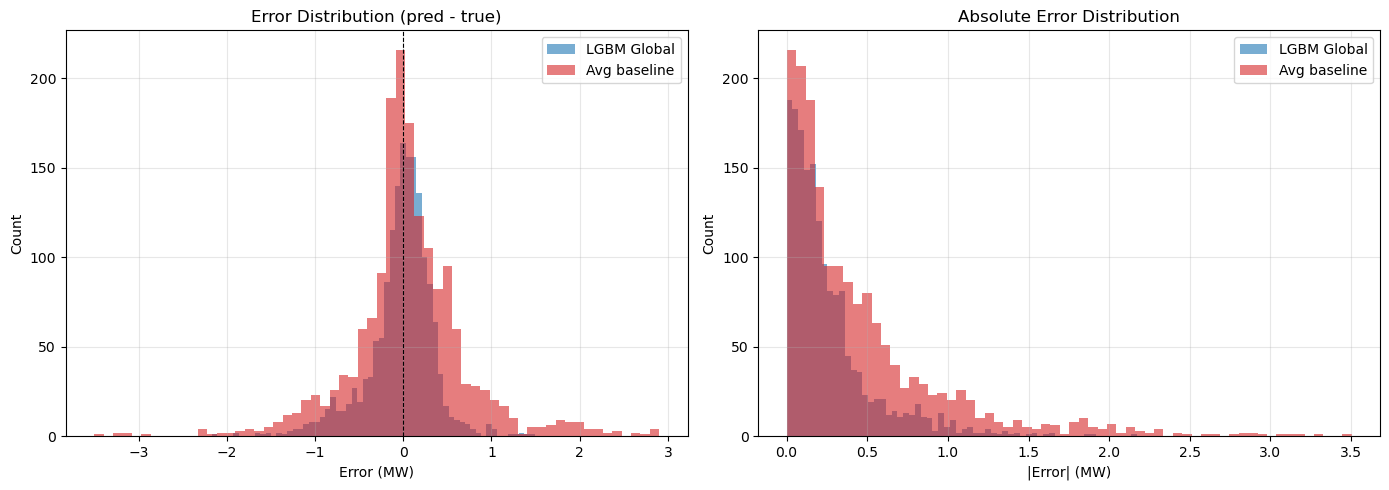

LGBM Global  — mean error: -0.0311 MW, std: 0.3804
Avg baseline — mean error: 0.0535 MW, std: 0.6780


In [24]:
err_lgbm = predictions["y_pred_mw"] - predictions["y_true_mw"]
err_base = avg_preds["y_pred"] - avg_preds["y_true"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, vals, title, xlabel in [
    (axes[0], [err_lgbm, err_base], "Error Distribution (pred - true)", "Error (MW)"),
    (axes[1], [np.abs(err_lgbm), np.abs(err_base)], "Absolute Error Distribution", "|Error| (MW)"),
]:
    ax.hist(vals[0], bins=60, alpha=0.6, label="LGBM Global", color="tab:blue")
    ax.hist(vals[1], bins=60, alpha=0.6, label="Avg baseline", color="tab:red")
    if "Absolute" not in title:
        ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
    ax.set(title=title, xlabel=xlabel, ylabel="Count")
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"LGBM Global  — mean error: {err_lgbm.mean():.4f} MW, std: {err_lgbm.std():.4f}")
print(f"Avg baseline — mean error: {err_base.mean():.4f} MW, std: {err_base.std():.4f}")

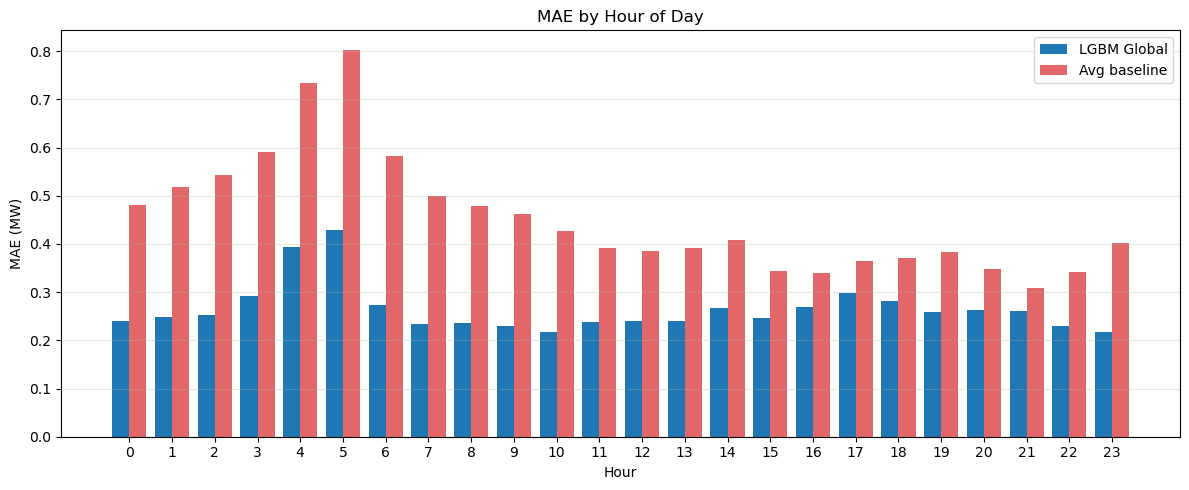

In [25]:
predictions["hour"] = pd.to_datetime(predictions["timestamp"]).dt.hour
avg_preds["hour"] = pd.to_datetime(avg_preds["timestamp"]).dt.hour

hourly_lgbm = predictions.groupby("hour").apply(
    lambda g: mae(g["y_true_mw"], g["y_pred_mw"]), include_groups=False)
hourly_base = avg_preds.groupby("hour").apply(
    lambda g: mae(g["y_true"], g["y_pred"]), include_groups=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly_lgbm.index - 0.2, hourly_lgbm.values, width=0.4, label="LGBM Global", color="tab:blue")
ax.bar(hourly_base.index + 0.2, hourly_base.values, width=0.4, label="Avg baseline", color="tab:red", alpha=0.7)
ax.set(title="MAE by Hour of Day", xlabel="Hour", ylabel="MAE (MW)")
ax.set_xticks(range(24)); ax.legend(); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_19031/2554746395.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_lgbm = predictions.groupby("location").apply(
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_19031/2554746395.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_base = avg_preds.groupby("location").apply(


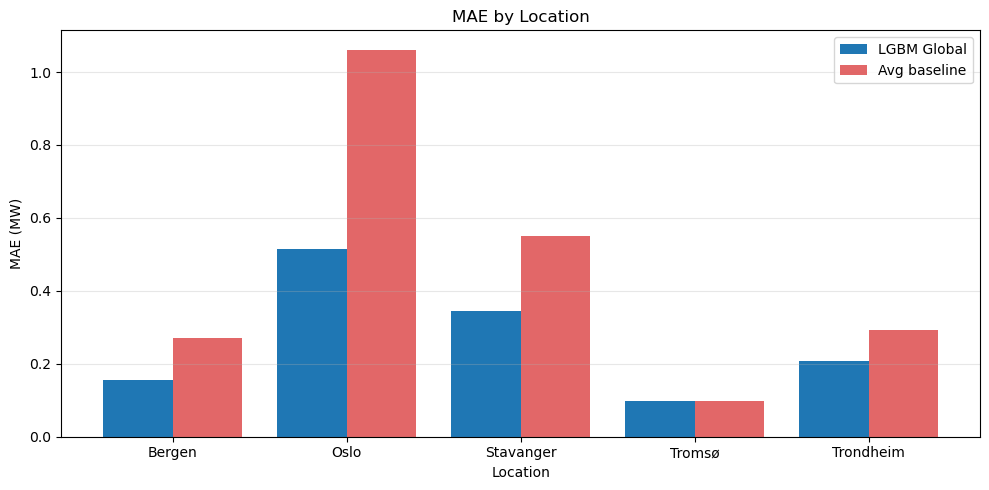

In [26]:
loc_lgbm = predictions.groupby("location").apply(
    lambda g: mae(g["y_true_mw"], g["y_pred_mw"]), include_groups=False)
loc_base = avg_preds.groupby("location").apply(
    lambda g: mae(g["y_true"], g["y_pred"]), include_groups=False)

x = np.arange(len(loc_lgbm))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 0.2, loc_lgbm.values, width=0.4, label="LGBM Global", color="tab:blue")
ax.bar(x + 0.2, loc_base.values, width=0.4, label="Avg baseline", color="tab:red", alpha=0.7)
ax.set(title="MAE by Location", xlabel="Location", ylabel="MAE (MW)")
ax.set_xticks(x); ax.set_xticklabels([n.capitalize() for n in loc_lgbm.index])
ax.legend(); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

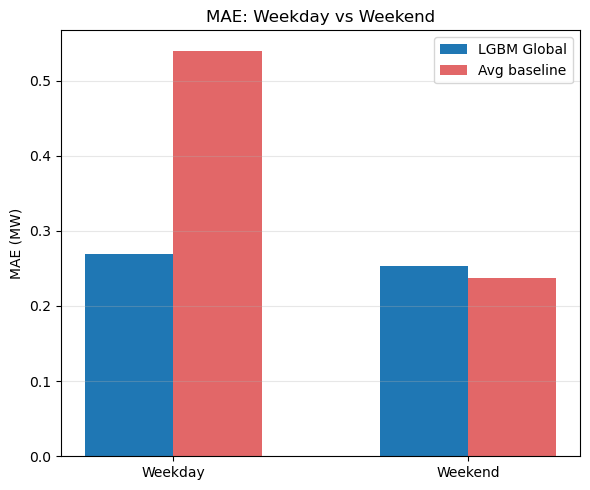

In [27]:
predictions["is_wknd"] = pd.to_datetime(predictions["timestamp"]).dt.dayofweek >= 5
avg_preds["is_wknd"] = pd.to_datetime(avg_preds["timestamp"]).dt.dayofweek >= 5

lgbm_wk = [mae(g["y_true_mw"], g["y_pred_mw"]) for _, g in predictions.groupby("is_wknd")]
base_wk = [mae(g["y_true"], g["y_pred"]) for _, g in avg_preds.groupby("is_wknd")]

x = np.arange(2)
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(x - 0.15, lgbm_wk, width=0.3, label="LGBM Global", color="tab:blue")
ax.bar(x + 0.15, base_wk, width=0.3, label="Avg baseline", color="tab:red", alpha=0.7)
ax.set(title="MAE: Weekday vs Weekend", ylabel="MAE (MW)")
ax.set_xticks(x); ax.set_xticklabels(["Weekday", "Weekend"])
ax.legend(); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## 9. Model Diagnostics

### 9.1 Feature Importance

Total gain importance from the model trained on the last test split.

/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_19031/1232580367.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_means = data.loc[X_train.index].groupby("location")["consumption"].mean()


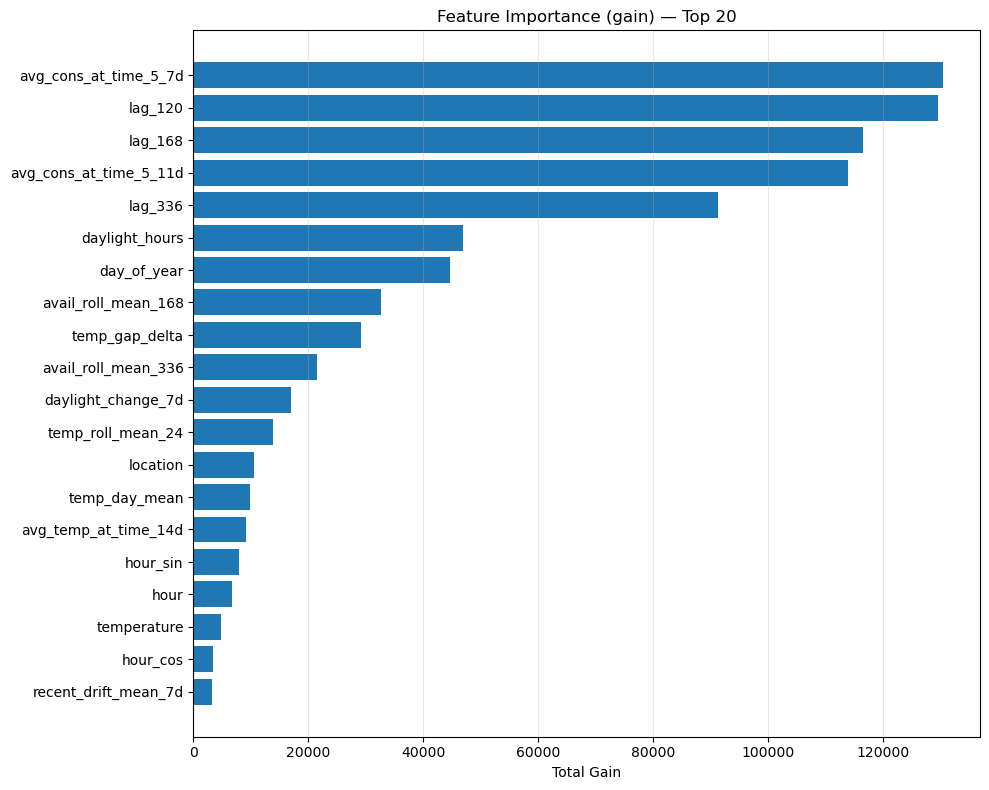

In [28]:
last = test_splits[-1]
fi_model = make_model({**best_params, "n_estimators": best_n_estimators})
weights = location_balance_weights(last.X_train)
fi_model.fit(last.X_train, last.y_train,
             sample_weight=weights, categorical_feature=cat_features)

imp = pd.DataFrame({
    "feature": last.X_train.columns.tolist(),
    "gain": fi_model.booster_.feature_importance(importance_type="gain"),
}).sort_values("gain", ascending=False)

top = imp.head(min(20, len(imp))).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top["feature"], top["gain"], color="tab:blue")
ax.set(title=f"Feature Importance (gain) — Top {len(top)}", xlabel="Total Gain")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

### 9.2 Partial Dependence

The model's learned response to key features in isolation.

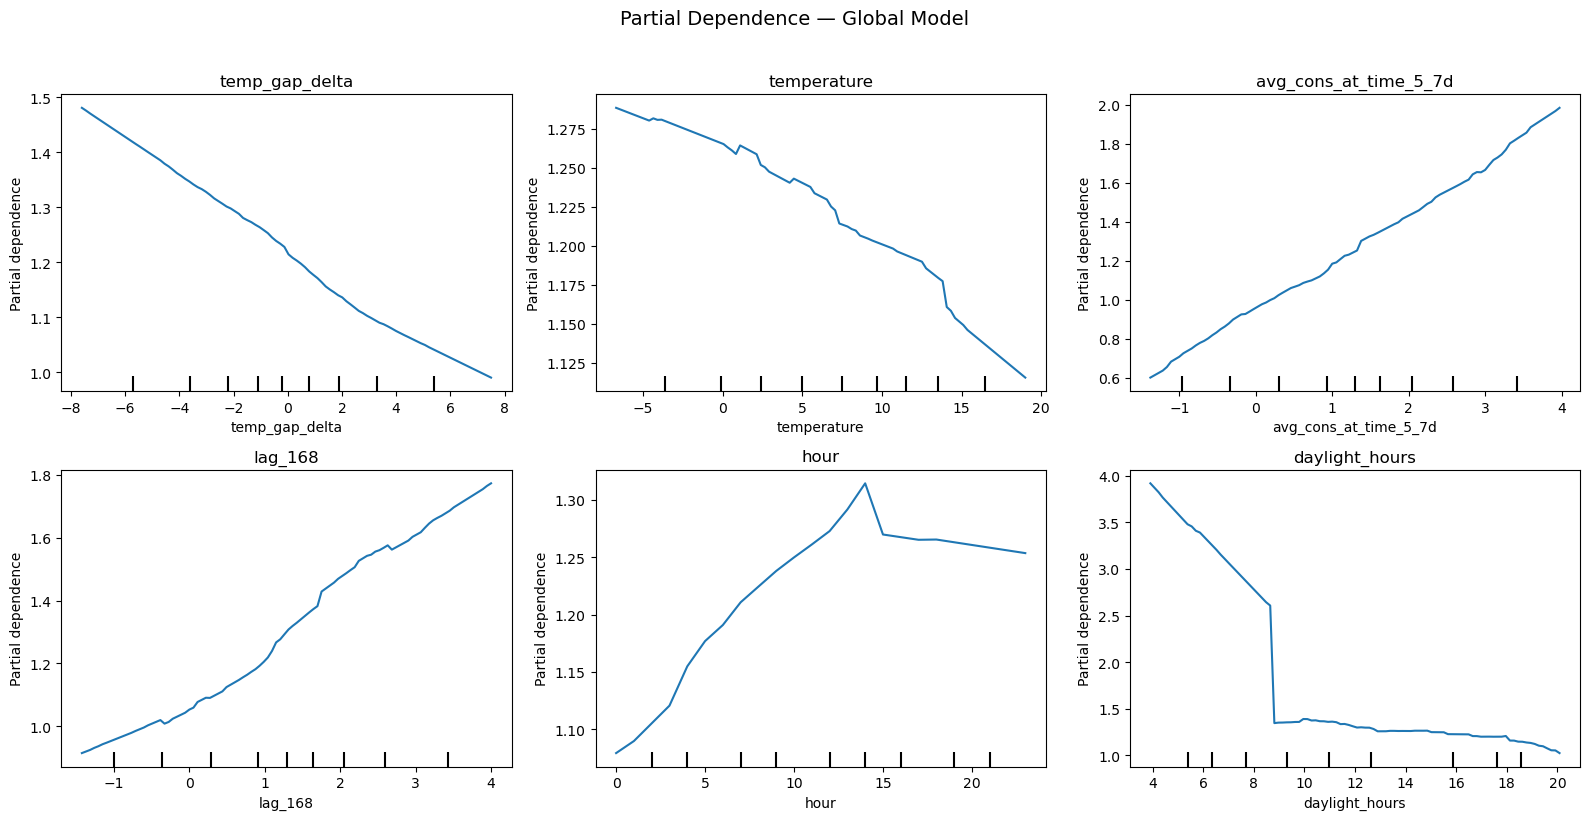

In [52]:
key_features = [f for f in [
    "temp_gap_delta",
    "temperature",
    "avg_cons_at_time_5_7d",
    "lag_168",
    "hour",
    "daylight_hours",
] if f in last.X_train.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feat in zip(axes.flat, key_features):
    X_plot = last.X_train.copy()
    if feat in ["hour", "day_of_year"]:
        X_plot[feat] = X_plot[feat].astype(float)
    PartialDependenceDisplay.from_estimator(
        fi_model, X_plot, [feat], ax=ax, line_kw={"color": "tab:blue"})
    ax.set_title(feat); ax.grid(True, alpha=0.3)
plt.suptitle("Partial Dependence — Global Model", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 9.3 Residual Autocorrelation

Autocorrelation of prediction errors at lags 1–48 hours per location. Bars within the red bands indicate uncorrelated (random) errors.

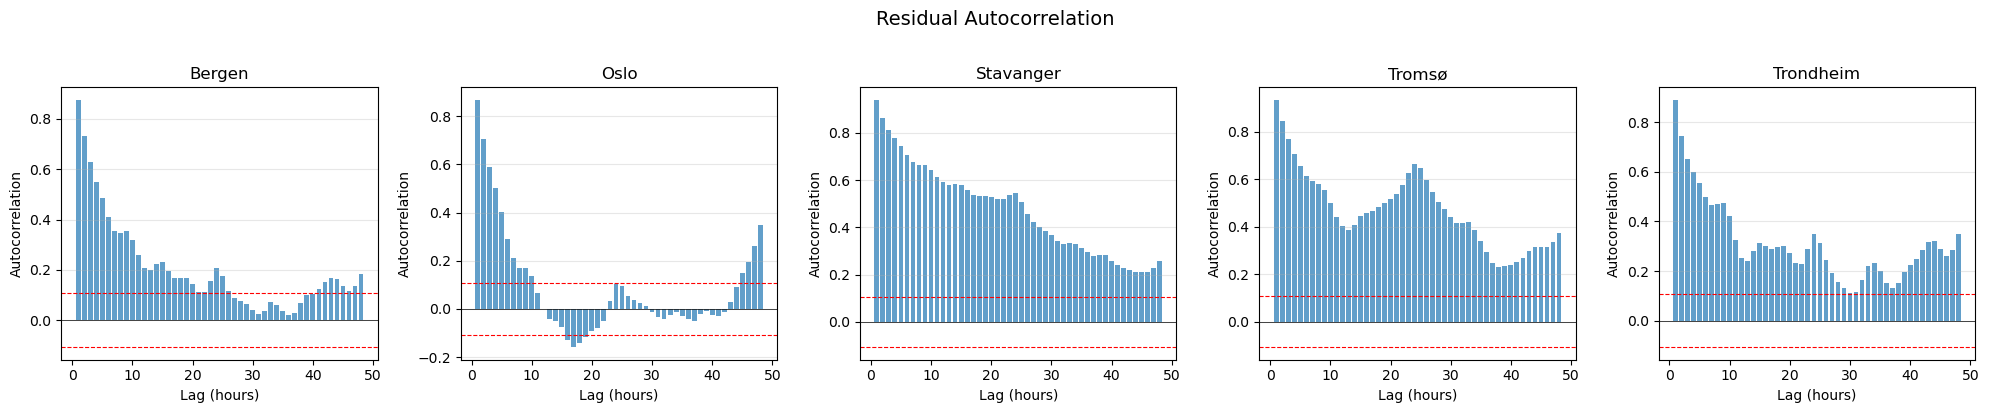

In [30]:
fig, axes = plt.subplots(1, len(predictions["location"].unique()),
                         figsize=(4 * len(predictions["location"].unique()), 4))

for ax, loc in zip(axes, sorted(predictions["location"].unique())):
    ld = predictions[predictions["location"] == loc].sort_values("timestamp")
    res = ld["y_pred_mw"].values - ld["y_true_mw"].values
    max_lag = min(48, len(res) - 1)
    ac = [np.corrcoef(res[:-lag], res[lag:])[0, 1] for lag in range(1, max_lag + 1)]

    ax.bar(range(1, max_lag + 1), ac, color="tab:blue", alpha=0.7)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axhline(1.96 / np.sqrt(len(res)), color="red", linestyle="--", linewidth=0.8)
    ax.axhline(-1.96 / np.sqrt(len(res)), color="red", linestyle="--", linewidth=0.8)
    ax.set(title=loc.capitalize(), xlabel="Lag (hours)", ylabel="Autocorrelation")
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Residual Autocorrelation", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 9.4 Tree Structure Analysis

Leaf value distribution and most common split features across all trees.

Total leaves: 1869, mean value: 0.0045, std: 0.0788


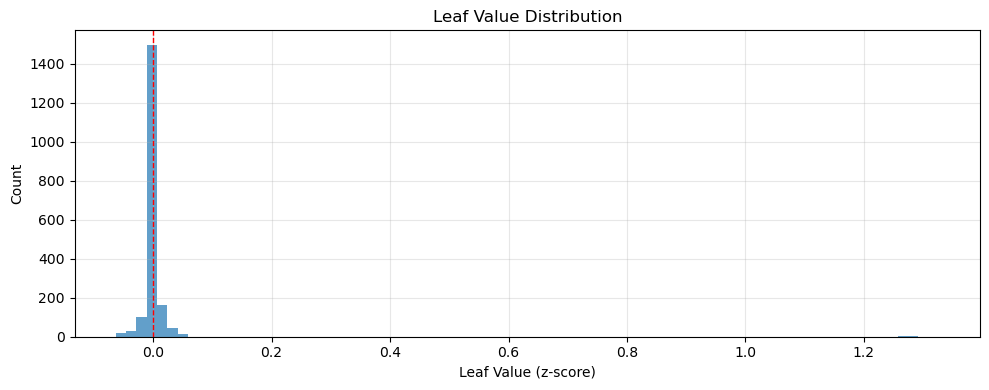

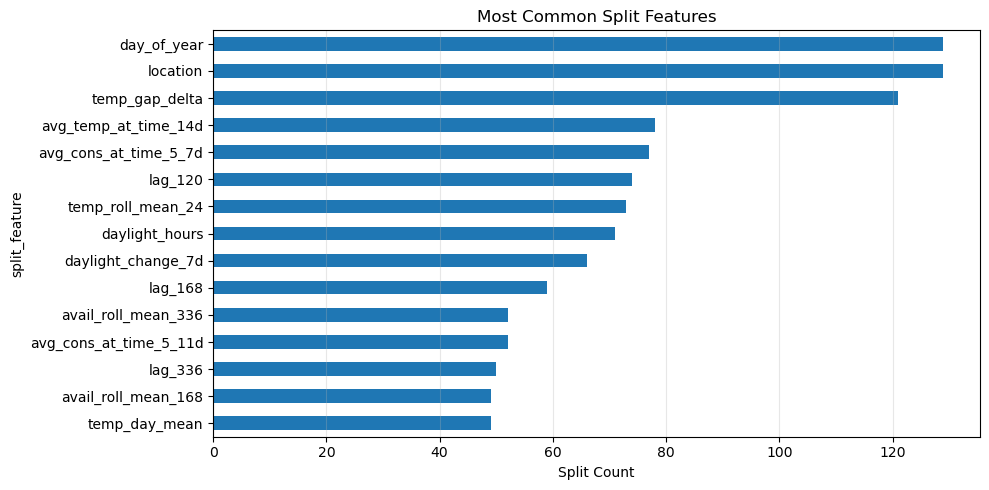

In [31]:
trees_df = fi_model.booster_.trees_to_dataframe()

leaf_rows = trees_df[trees_df["left_child"].isna()]
print(f"Total leaves: {len(leaf_rows)}, mean value: {leaf_rows['value'].mean():.4f}, "
      f"std: {leaf_rows['value'].std():.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(leaf_rows["value"], bins=80, color="tab:blue", alpha=0.7)
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set(title="Leaf Value Distribution", xlabel="Leaf Value (z-score)", ylabel="Count")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

split_rows = trees_df[trees_df["left_child"].notna()]
split_counts = split_rows["split_feature"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
split_counts.iloc[::-1].plot.barh(ax=ax, color="tab:blue")
ax.set(title="Most Common Split Features", xlabel="Split Count")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

## 10. Model Comparison

In [32]:
def evaluate_model(name, model, test_splits, needs_scaling=False, needs_onehot=False):
    """Train and evaluate an alternative model on the same test splits."""
    pred_rows = []

    for split in test_splits:
        X_train = split.X_train.copy()
        X_test = split.X_test.copy()
        y_train = split.y_train.values

        for col in X_train.select_dtypes(include=["category"]).columns:
            if col != "location":
                X_train[col] = X_train[col].astype(float)
                X_test[col] = X_test[col].astype(float)

        if needs_onehot:
            X_train["location"] = X_train["location"].astype(str)
            X_test["location"] = X_test["location"].astype(str)
            X_train = pd.get_dummies(X_train, columns=["location"])
            X_test = pd.get_dummies(X_test, columns=["location"])
            X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

        if needs_scaling:
            num_cols = X_train.select_dtypes(include=[np.number]).columns
            scaler = StandardScaler()
            X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
            X_test[num_cols] = scaler.transform(X_test[num_cols])

        if not needs_onehot:
            X_train = X_train.select_dtypes(include=[np.number])
            X_test = X_test.select_dtypes(include=[np.number])

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        pred_rows.append(pd.DataFrame({
            "forecast_date": split.forecast_date,
            "timestamp": split.X_test.index,
            "location": split.X_test["location"].values,
            "y_true": split.y_test.values,
            "y_pred": y_pred,
        }))

    preds = pd.concat(pred_rows, ignore_index=True)
    preds = invert_standardization(preds, data)

    overall_smape = smape(preds["y_true_mw"], preds["y_pred_mw"])
    overall_mae = mae(preds["y_true_mw"], preds["y_pred_mw"])
    overall_rmse = rmse(preds["y_true_mw"], preds["y_pred_mw"])

    print(f"\n{name}")
    print(f"  Overall: MAE={overall_mae:.4f} MW, RMSE={overall_rmse:.4f} MW, SMAPE={overall_smape:.2f}%")
    for loc in sorted(preds["location"].unique()):
        ld = preds[preds["location"] == loc]
        print(f"  {loc.capitalize():12s}: MAE={mae(ld['y_true_mw'], ld['y_pred_mw']):.4f}, "
              f"RMSE={rmse(ld['y_true_mw'], ld['y_pred_mw']):.4f}, "
              f"SMAPE={smape(ld['y_true_mw'], ld['y_pred_mw']):.2f}%")

    return preds, overall_smape, overall_mae, overall_rmse


# --- Ridge Regression ---
ridge_preds, ridge_smape, ridge_mae, ridge_rmse = evaluate_model(
    "Ridge Regression (alpha=1.0)",
    Ridge(alpha=1.0),
    test_splits, needs_scaling=True, needs_onehot=True,
)

# --- XGBoost ---
xgb_preds, xgb_smape, xgb_mae, xgb_rmse = evaluate_model(
    "XGBoost (default params)",
    XGBRegressor(
        n_estimators=best_n_estimators, learning_rate=0.05,
        max_depth=5, subsample=0.8, colsample_bytree=0.7,
        objective="reg:absoluteerror", random_state=42,
        verbosity=0,
    ),
    test_splits, needs_scaling=False, needs_onehot=True,
)

# --- MLP ---
mlp_preds, mlp_smape, mlp_mae, mlp_rmse = evaluate_model(
    "MLP (2 hidden layers)",
    MLPRegressor(
        hidden_layer_sizes=(128, 64), max_iter=500,
        early_stopping=True, validation_fraction=0.1,
        random_state=42,
    ),
    test_splits, needs_scaling=True, needs_onehot=True,
)

# --- Summary ---
comparison = pd.DataFrame({
    "Model": ["Avg Baseline", "Ridge Regression", "XGBoost", "MLP (2-layer)", "LightGBM (ours)"],
    "MAE": [avg_metrics["MAE"].mean(), ridge_mae, xgb_mae, mlp_mae, daily_metrics["MAE"].mean()],
    "RMSE": [avg_metrics["RMSE"].mean(), ridge_rmse, xgb_rmse, mlp_rmse, daily_metrics["RMSE"].mean()],
    "SMAPE_%": [avg_metrics["SMAPE_%"].mean(), ridge_smape, xgb_smape, mlp_smape, daily_metrics["SMAPE_%"].mean()],
}).sort_values("SMAPE_%").reset_index(drop=True)

display(comparison)


Ridge Regression (alpha=1.0)
  Overall: MAE=0.4558 MW, RMSE=0.6986 MW, SMAPE=9.85%
  Bergen      : MAE=0.2511, RMSE=0.2962, SMAPE=9.27%
  Oslo        : MAE=1.2204, RMSE=1.4145, SMAPE=11.89%
  Stavanger   : MAE=0.2976, RMSE=0.3797, SMAPE=5.91%
  Tromsø      : MAE=0.2410, RMSE=0.3160, SMAPE=14.25%
  Trondheim   : MAE=0.2688, RMSE=0.3279, SMAPE=7.93%

XGBoost (default params)
  Overall: MAE=0.3594 MW, RMSE=0.4794 MW, SMAPE=7.94%
  Bergen      : MAE=0.2435, RMSE=0.2820, SMAPE=8.51%
  Oslo        : MAE=0.6534, RMSE=0.7852, SMAPE=5.98%
  Stavanger   : MAE=0.4839, RMSE=0.5693, SMAPE=9.43%
  Tromsø      : MAE=0.1538, RMSE=0.1768, SMAPE=8.13%
  Trondheim   : MAE=0.2624, RMSE=0.3123, SMAPE=7.64%

MLP (2 hidden layers)
  Overall: MAE=0.3748 MW, RMSE=0.5171 MW, SMAPE=8.31%
  Bergen      : MAE=0.2980, RMSE=0.3637, SMAPE=10.21%
  Oslo        : MAE=0.7057, RMSE=0.8896, SMAPE=6.47%
  Stavanger   : MAE=0.4050, RMSE=0.5041, SMAPE=7.86%
  Tromsø      : MAE=0.1472, RMSE=0.1727, SMAPE=7.87%
  Trondheim   

,Model,MAE,RMSE,SMAPE_%
0,LightGBM (ours),0.265069,0.373067,5.644885
1,XGBoost,0.359402,0.479381,7.940520
2,MLP (2-layer),0.374810,0.517078,8.312147
3,Avg Baseline,0.453011,0.637559,8.714729
4,Ridge Regression,0.455766,0.698575,9.851126


In [33]:
comparison.to_csv("model_comparison.csv", index=False)

## 11. SHAP LIME Plots

SHAP and LIME visualizes the decision-making process of the model. The packages does **not** support Linear Trees in LGBM, thus a proxy model is created with the same hyper parameters, _without_ Linear Trees to mimic the actual model's behaviour. The results must be interpreted in light of this. The fidelity of the models is documented below.

In [51]:
last = test_splits[-1]
weights = location_balance_weights(last.X_train)

# Real model (current pipeline)
actual_params = {**best_params, "n_estimators": best_n_estimators}
actual_model = make_model(actual_params)
actual_model.fit(
    last.X_train,
    last.y_train,
    sample_weight=weights,
    categorical_feature=cat_features,
)

# Matched proxy for interpretability
proxy_params = {**best_params, "n_estimators": best_n_estimators, "linear_tree": False}
proxy_model = make_model(proxy_params)
proxy_model.fit(
    last.X_train,
    last.y_train,
    sample_weight=weights,
    categorical_feature=cat_features,
)

# Fidelity of proxy to actual model
y_actual = actual_model.predict(last.X_test)
y_proxy  = proxy_model.predict(last.X_test)

fidelity = pd.Series({
    "proxy vs actual | MAE":  mae(y_actual, y_proxy),
    "proxy vs actual | RMSE": rmse(y_actual, y_proxy),
    "proxy vs actual | R2":   r2_score(y_actual, y_proxy),
    "proxy vs actual | corr": np.corrcoef(y_actual, y_proxy)[0, 1],
})

print("Fidelity of proxy model to actual model:")
print(fidelity)

/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_19031/1232580367.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_means = data.loc[X_train.index].groupby("location")["consumption"].mean()


Fidelity of proxy model to actual model:
proxy vs actual | MAE     0.095771
proxy vs actual | RMSE    0.120037
proxy vs actual | R2      0.500179
proxy vs actual | corr    0.887414
dtype: float64


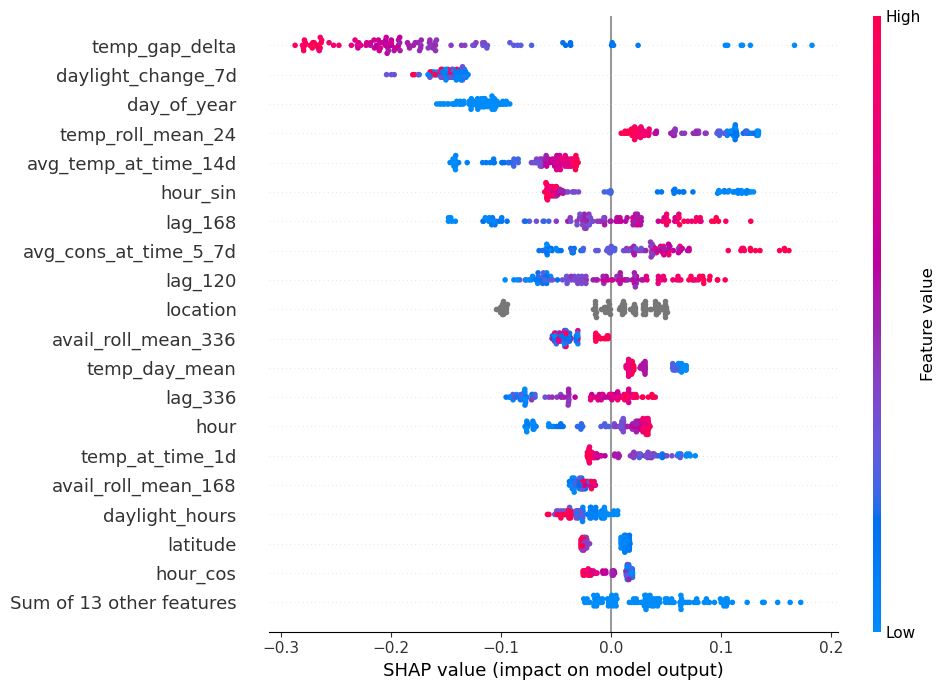

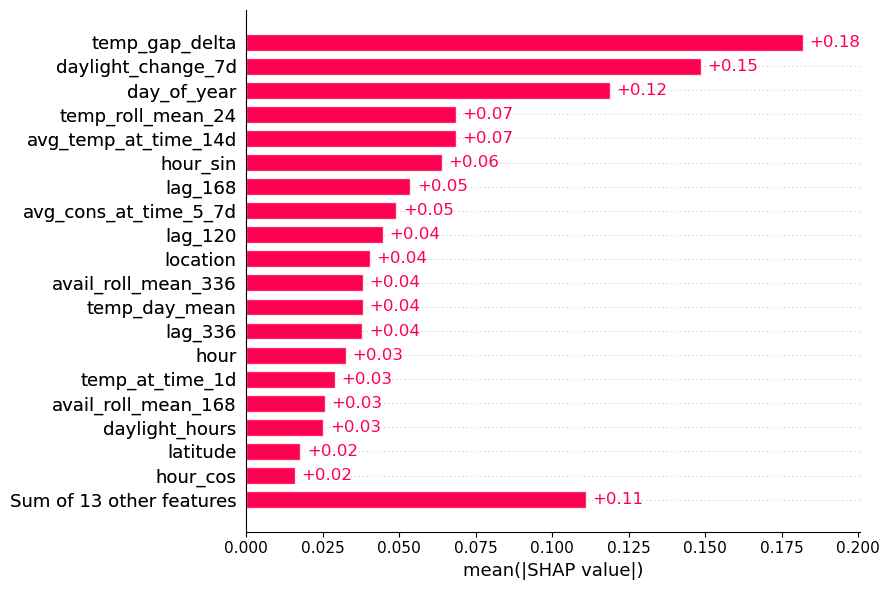

In [41]:
X_explain = last.X_test.copy()

explainer = shap.TreeExplainer(proxy_model)
shap_values = explainer(X_explain)

# Beeswarm
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.gcf().set_size_inches(10, 7)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", bbox_inches="tight")
plt.show()

# Mean absolute SHAP bar plot
shap.plots.bar(shap_values, max_display=20, show=False)
plt.gcf().set_size_inches(9, 6)
plt.tight_layout()
plt.savefig("shap_bar.png", bbox_inches="tight")
plt.show()

In [ ]:
last = test_splits[-1]

# Use the same proxy model as SHAP

train_template = last.X_train.copy()
feature_names = train_template.columns.tolist()
location_dtype = train_template["location"].dtype
location_categories = list(train_template["location"].cat.categories)
location_ordered = train_template["location"].cat.ordered

loc_idx = feature_names.index("location")

def encode_lime_df(X_df: pd.DataFrame) -> np.ndarray:
    X = X_df.copy()
    X["location"] = X["location"].cat.codes.astype(float)

    for col in feature_names:
        if col != "location":
            X[col] = X[col].astype(float)

    return X[feature_names].to_numpy()


def decode_lime_array(X_numeric: np.ndarray) -> pd.DataFrame:
    X = pd.DataFrame(X_numeric, columns=feature_names)

    for col in feature_names:
        if col != "location":
            X[col] = X[col].astype(train_template[col].dtype)

    loc_codes = np.rint(X["location"]).astype(int)
    loc_codes = np.clip(loc_codes, 0, len(location_categories) - 1)

    X["location"] = pd.Categorical.from_codes(
        loc_codes,
        categories=location_categories,
        ordered=location_ordered,
    )

    X["location"] = X["location"].astype(location_dtype)

    return X[feature_names]


X_train_lime = encode_lime_df(last.X_train)
X_test_lime = encode_lime_df(last.X_test)

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_lime,
    feature_names=feature_names,
    categorical_features=[loc_idx],
    categorical_names={loc_idx: location_categories},
    mode="regression",
    random_state=42,
    discretize_continuous=False,
)

def lime_predict_proxy(X_numeric):
    X_decoded = decode_lime_array(X_numeric)
    return interp_model.predict(X_decoded)

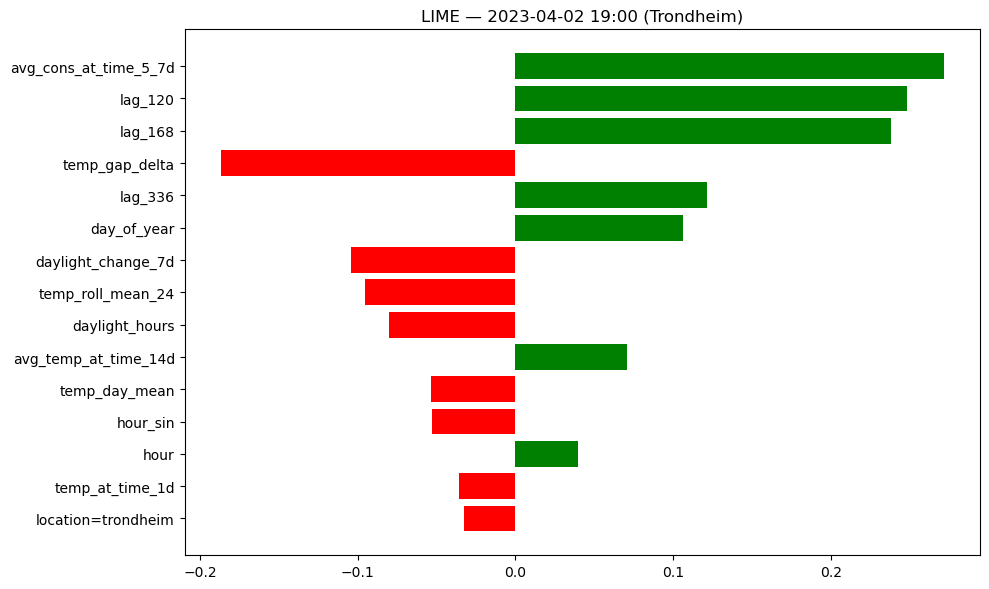

Instance:      2023-04-02 19:00:00 | location: Trondheim
Predicted (z): 1.2466
Local R^2:     0.824


In [48]:
target_location = "trondheim"

loc_series = (
    last.X_test["location"]
    .astype(str)
    .str.strip()
    .str.lower()
)

candidate_idx = np.flatnonzero(loc_series.eq(target_location).to_numpy())

if len(candidate_idx) == 0:
    print("No matching rows found.")
    print("Available locations:", sorted(loc_series.unique()))
else:
    rows = []
    for i in candidate_idx:
        exp = lime_explainer.explain_instance(
            X_test_lime[i],
            lime_predict_proxy,
            num_features=15,
        )
        rows.append((i, exp.score))

    best_idx, best_r2 = max(rows, key=lambda t: t[1])

    lime_exp = lime_explainer.explain_instance(
        X_test_lime[best_idx],
        lime_predict_proxy,
        num_features=15,
    )

    ts = last.X_test.index[best_idx]
    loc = str(last.X_test.iloc[best_idx]["location"]).title()

    fig = lime_exp.as_pyplot_figure()
    fig.set_size_inches(10, 6)
    plt.title(f"LIME — {ts.date()} {ts.hour:02d}:00 ({loc})")
    plt.tight_layout()
    plt.savefig("lime_explanation.png", bbox_inches="tight")
    plt.show()

    print(f"Instance:      {ts} | location: {loc}")
    print(f"Predicted (z): {lime_exp.predicted_value:.4f}")
    print(f"Local R^2:     {lime_exp.score:.3f}")